In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("Weight of copper dataset.csv")
df.head()

,Unnamed: 0,power_rating,weight_of_copper,category
0,1,16.46,34.69,high
1,2,12.52,28.78,high
2,3,7.66,21.48,high
3,4,21.09,41.64,high
4,5,24.43,46.64,high


In [4]:
df = df.drop("Unnamed: 0",axis = 1) 
df.head()

,power_rating,weight_of_copper,category
0,16.46,34.69,high
1,12.52,28.78,high
2,7.66,21.48,high
3,21.09,41.64,high
4,24.43,46.64,high


In [5]:
K = {'low':0,'high':1} 
df['category'] = df['category'].map(K) 
X = df[["power_rating","weight_of_copper"]] 
Y = df[["category"]] 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33,random_state=42) 
from sklearn.ensemble import RandomForestClassifier 
clf = RandomForestClassifier(max_depth=2, random_state=0) 
clf.fit(X_train, y_train.values.ravel()) 

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = clf.predict (X_test) 
y_pred 

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [7]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score 
print("accuracy score",accuracy_score(y_test, y_pred)) 
print("mean_squared_error",mean_squared_error(y_test, y_pred)) 
from sklearn.metrics import confusion_matrix 

accuracy score 1.0
mean_squared_error 0.0


In [8]:
y_true = y_test 
data = confusion_matrix(y_true, y_pred) 
data 

array([[  4,   0],
       [  0, 140]])

In [9]:
import seaborn as sn 
df_cm = pd.DataFrame(data, columns=np.unique(y_true), index =np.unique(y_true)) 
df_cm.index.name = "Actual" 
df_cm.columns.name = "Predicted" 
plt.figure(figsize = (10,7)) 
sn.set(font_scale=1.4) 
df_cm 

Predicted,0,1
Actual,,
0,4,0
1,0,140


<Figure size 1000x700 with 0 Axes>

<Axes: xlabel='Predicted', ylabel='Actual'>

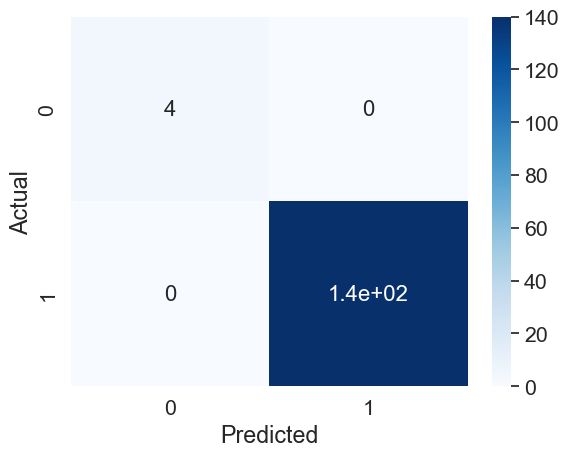

In [10]:
sn.heatmap(df_cm, cmap="Blues", annot=True,annot_kws= {"size":16}) 